# Tripartite Population Dynamics- paper 1

### Imports

In [3]:
from src.model import deriv
from src.parameters import parameters
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import os

## test analysis

In [4]:
from src.parameters import parameters
print(parameters)


{'beta': 0.0001, 'gamma': 0.0001, 'alpha': 0.0003, 'eta': 0.0001, 'r_c': 2.0, 'r_p': 1.0, 'nu': 0.0001}


# 1. Simulating with different initial ratio(cheater 1:5:10)


In [7]:
# Define initial conditions for different ratios
ratios = {
    "1:1:1": [100.0, 100.0, 100.0],  # C:D:P
    "1:5:1": [100.0, 500.0, 100.0],
    "1:10:1": [100.0, 1000.0, 100.0],
}

# Time points
t = np.linspace(0, 200, 500)


# Ensure output directory exists
os.makedirs("output/figures", exist_ok=True)

# Define colors for populations and line styles for ratios
colors = {"Public (P)": "green", "Cheater (C)": "black", "Private (M)": "orange"}
line_styles = {
    "1:1:1": "-",
    "1:5:1": "--",
    "1:10:1": ":",
}

def simulate_population(t, ratios, colors, line_styles, parameters, save_name_suffix):

    for population, idx in zip(["Public (P)", "Cheater (C)", "Private (M)"], range(3)):
        plt.figure(figsize=(10, 6))
        for label, y0 in ratios.items():
            # Solve the system of ODEs
            ret = odeint(deriv, y0, t, args=(
                parameters["nu"],
                parameters["beta"],
                parameters["alpha"],
                parameters["r_c"],
                parameters["r_p"],
                parameters["gamma"],
                parameters["eta"],
            ))
            
            # Plot the specific population with the correct color and line style
            legend_label = f"Public:Cheater:Private - {label}"
            plt.plot(
                t, ret[:, idx],
                color=colors[population],  # Correct color applied here
                linestyle=line_styles[label],  # Line style for the ratio
                label=legend_label
            )

        # Customize the plot
        plt.xlabel("Time(h)", fontsize=14, fontweight="bold")
        plt.ylabel("Population(cell)", fontsize=14,fontweight="bold" )
        plt.title(f"{population} Population Dynamics", fontsize=16)
        plt.legend(title="Initial Ratios", fontsize=10)
        plt.grid()
        plt.tight_layout()

        # Save the figure with a suffix to distinguish results
        output_file = f"output/figures/{population.replace(' ', '_').lower()}_{save_name_suffix}.png"
        plt.savefig(output_file, dpi=300)
        plt.show()


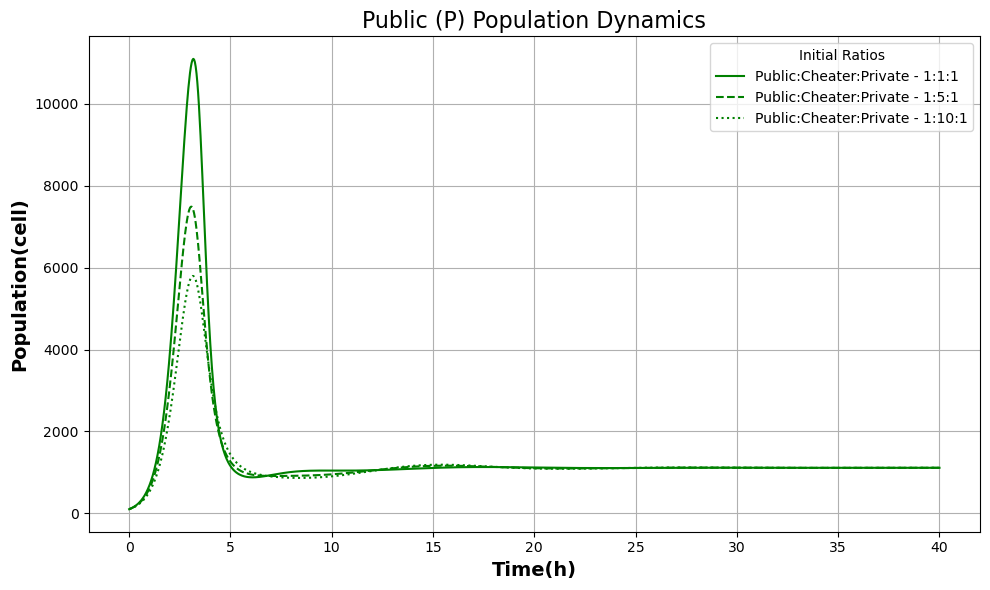

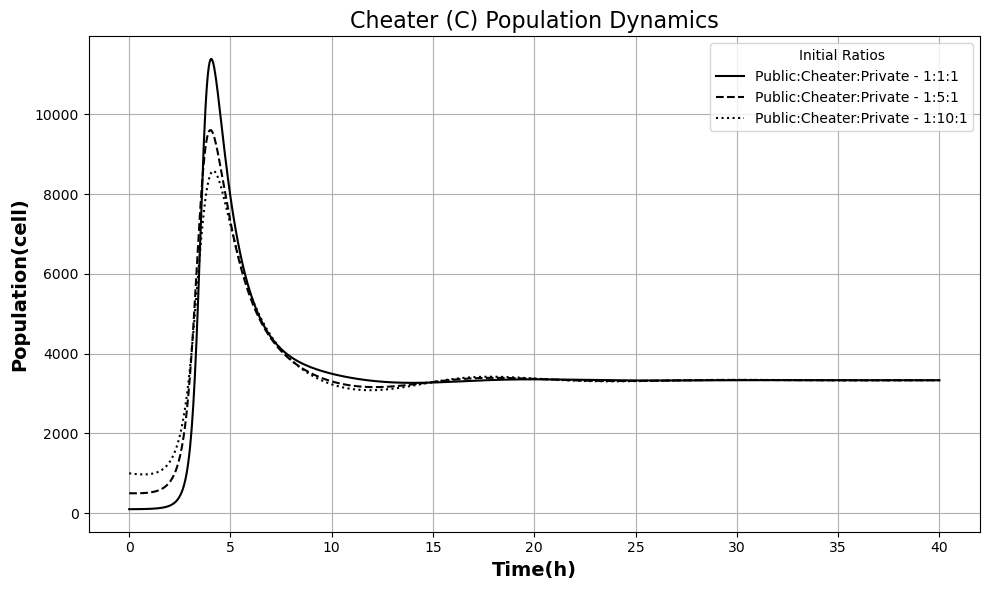

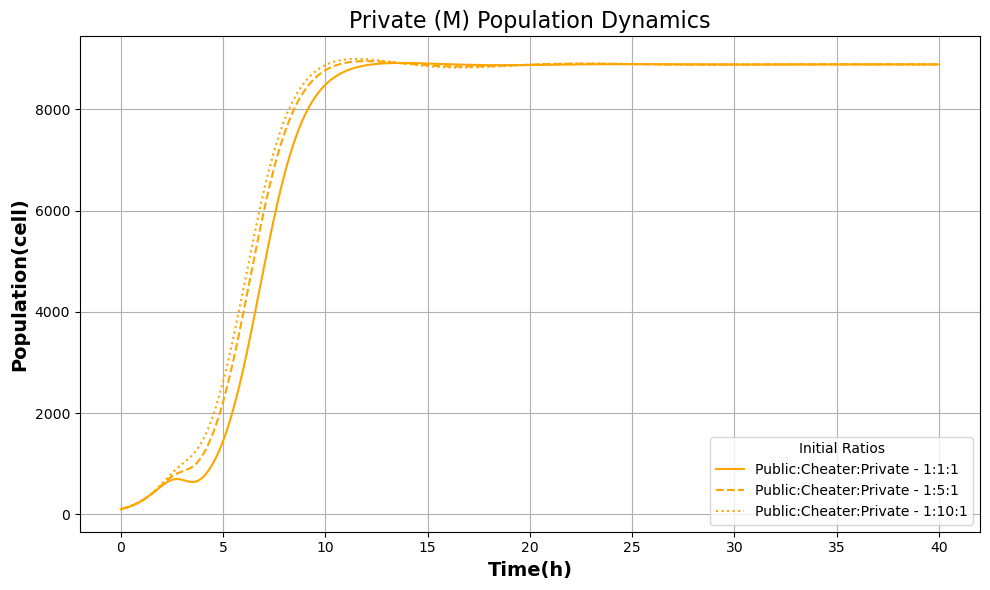

In [8]:
t_updated = np.linspace(0, 40, 1000)
simulate_population(t_updated, ratios, colors, line_styles, parameters, save_name_suffix="cheater_ra")

## longer time period

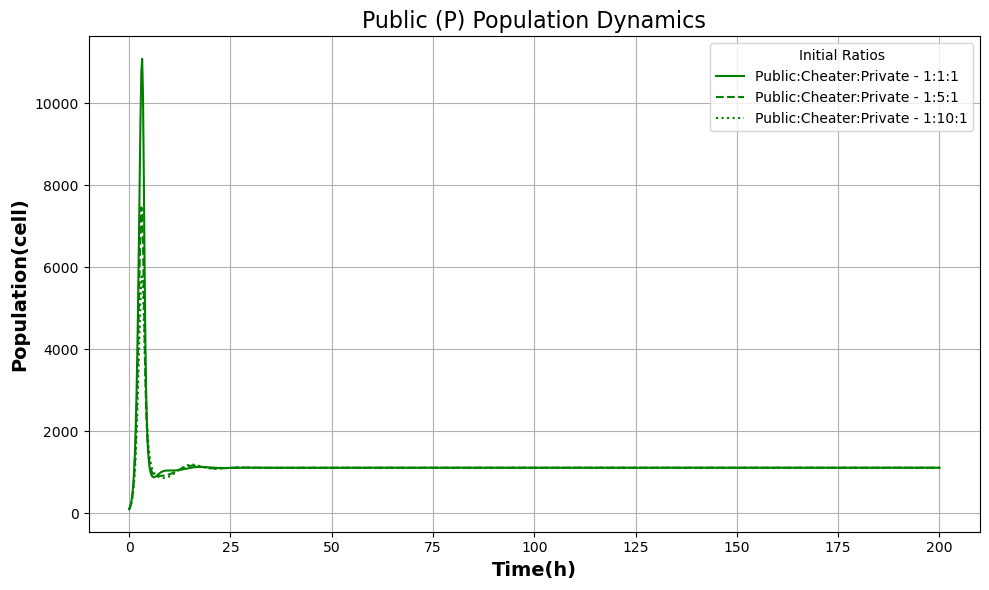

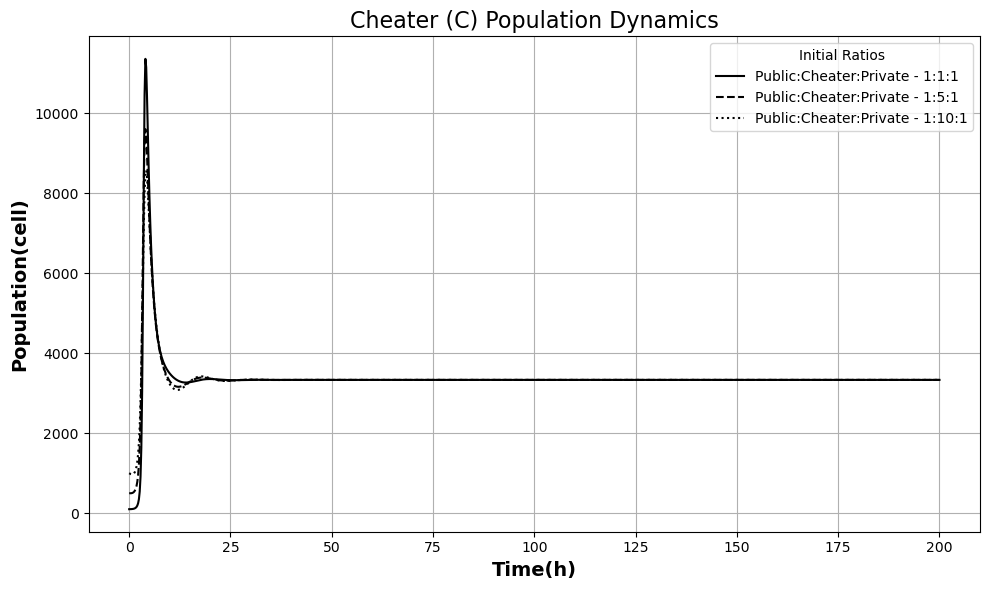

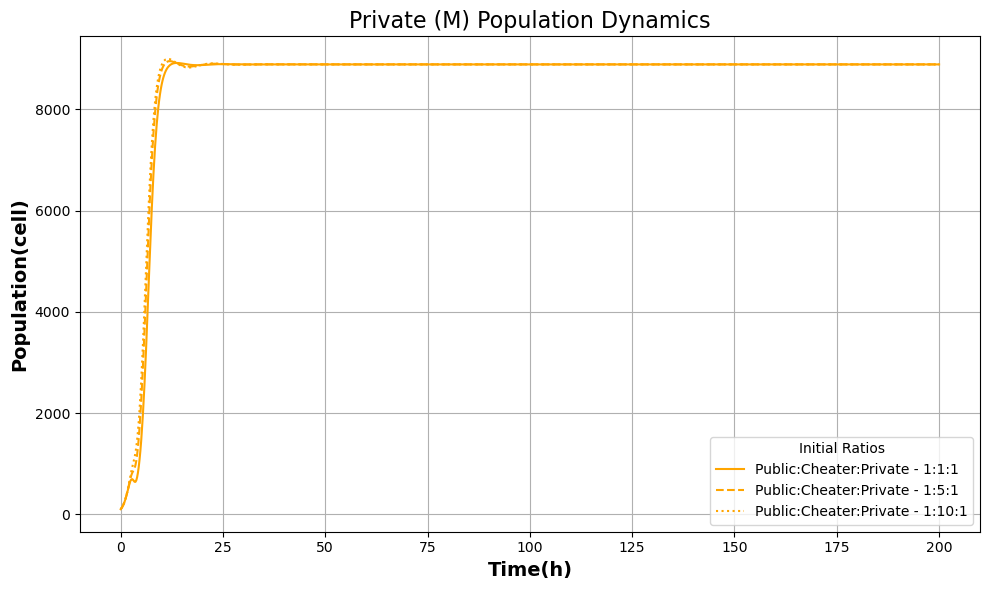

In [9]:
t_updated = np.linspace(0, 200, 1000)
simulate_population(t_updated, ratios, colors, line_styles, parameters, save_name_suffix="updated_time")

## higher ratio of public population(1:5:10)

In [1]:
# Updated ratios: Public (C) has initial ratio of 1, 5, and 10
ratios_updated = {
    "1:1:1": [100.0, 100.0, 100.0],  # C:D:P
    "5:1:1": [500.0, 100.0, 100.0],
    "10:1:1": [1000.0, 100.0, 100.0],
}

line_styles = {
    "1:1:1": "-",
    "5:1:1": "--",
    "10:1:1": ":",
}


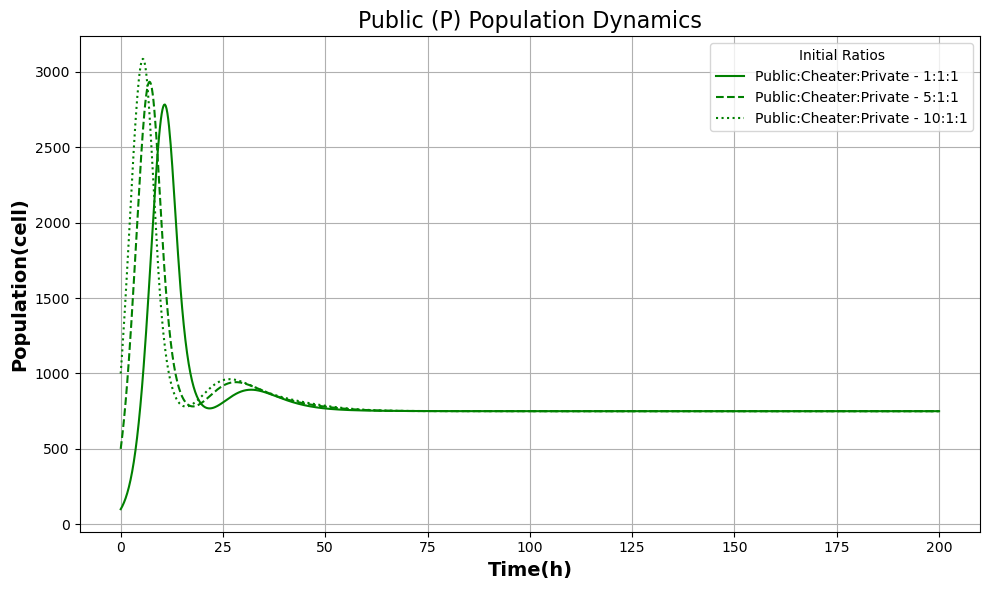

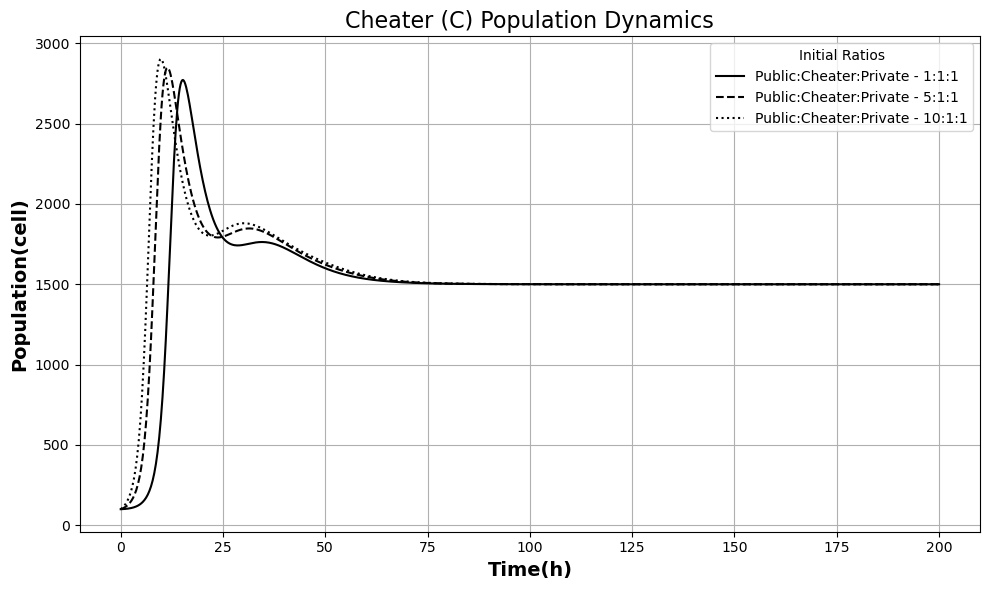

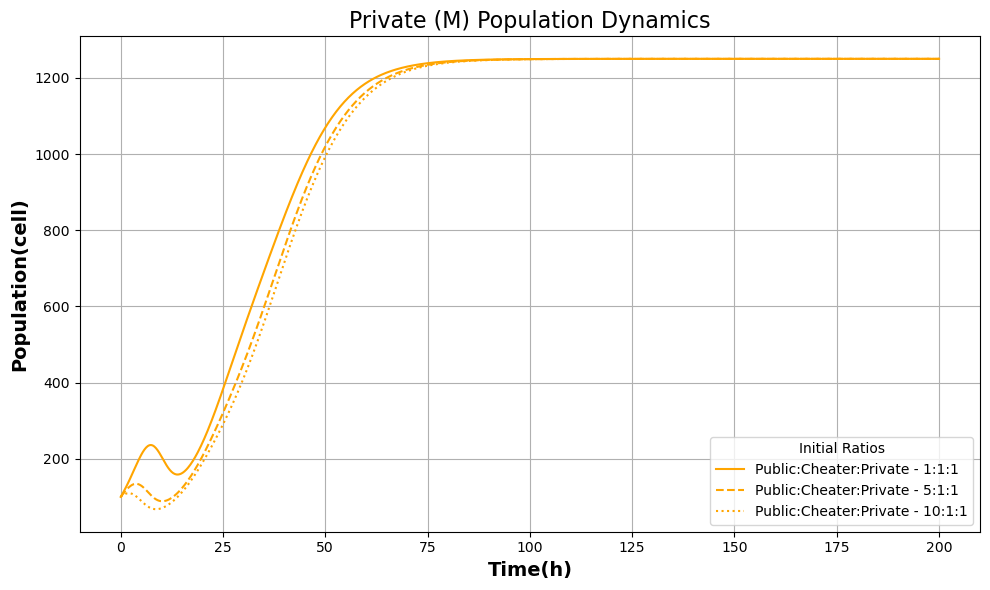

In [8]:
simulate_population(t_updated, ratios_updated, colors, line_styles, parameters, save_name_suffix="public_ratio")

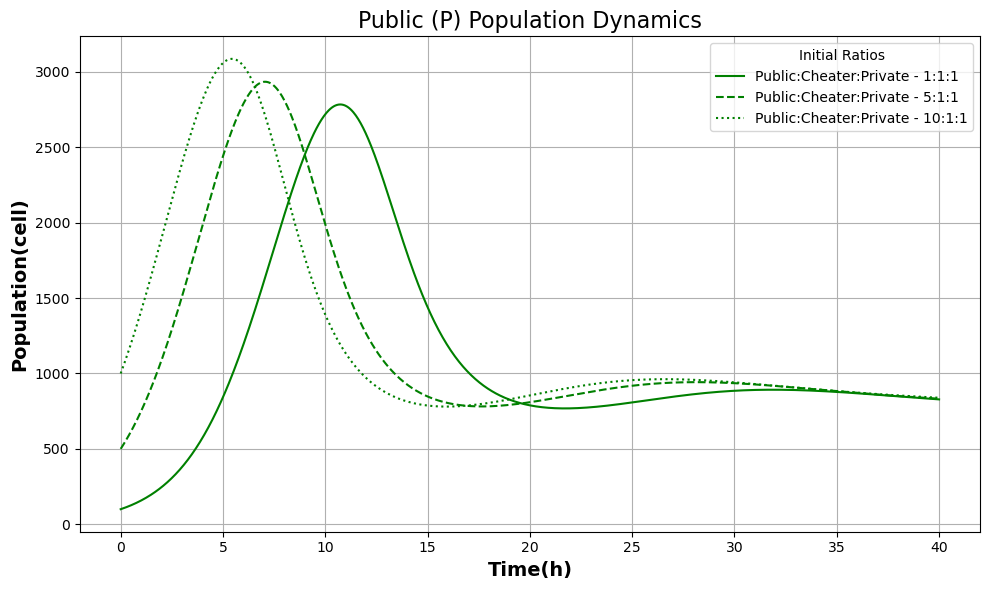

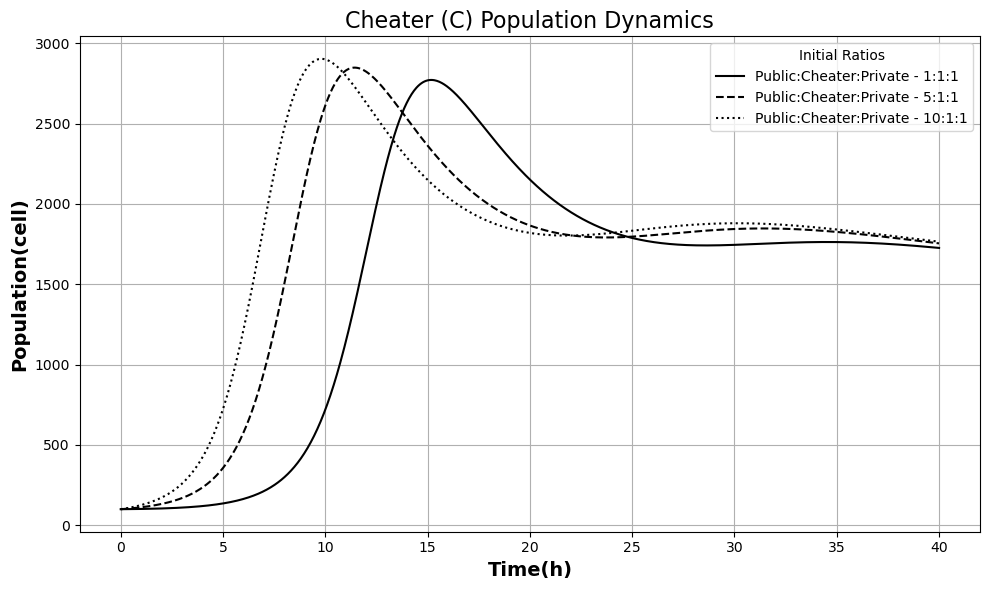

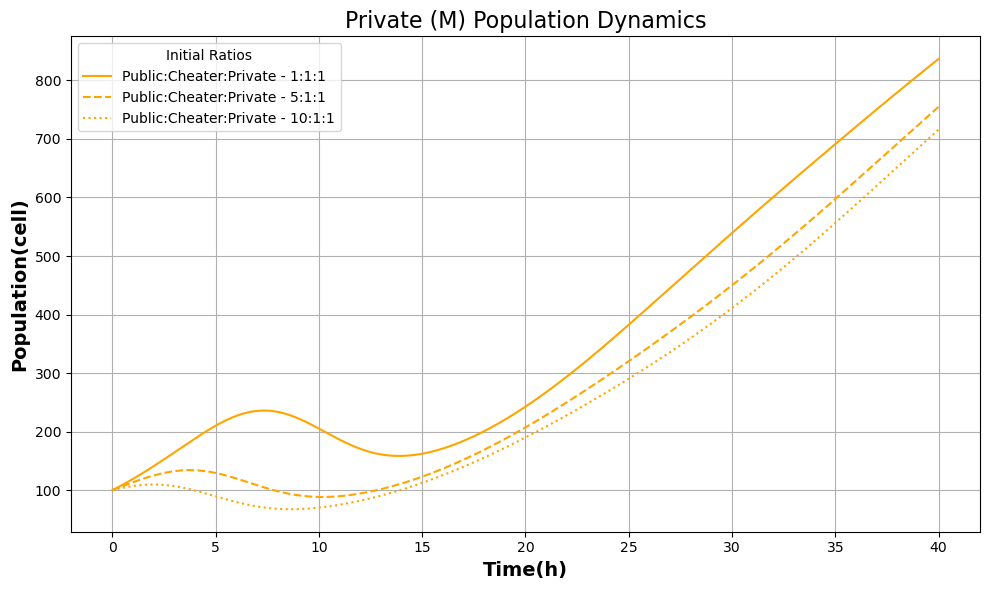

In [9]:
t_updated = np.linspace(0, 40, 1000)
simulate_population(t_updated, ratios_updated, colors, line_styles, parameters, save_name_suffix="public_ratio")

# 2. Stochastic dynamics in growth rate(supplementary material)
adding noise in growth condition

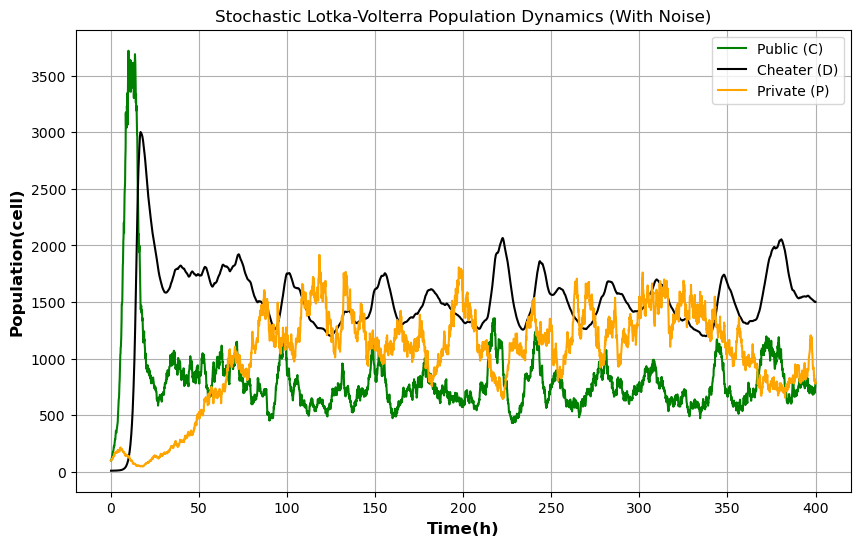

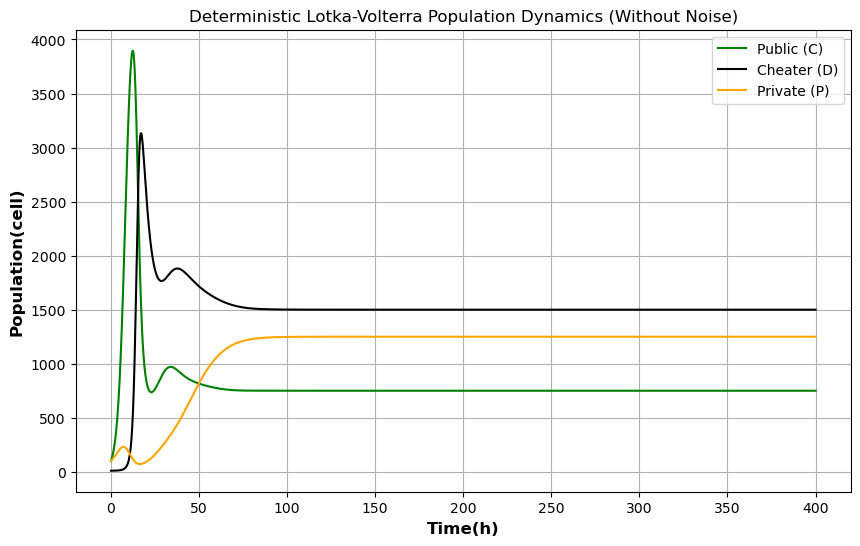

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from src.parameters import parameters

# Simulation Function
def simulate_population(T, dt, C0, D0, P0, params, noise=True):
    # Simulation parameters
    n_steps = int(T / dt)
    time = np.linspace(0, T, n_steps)

    # Arrays to store population values
    C = np.zeros(n_steps)
    D = np.zeros(n_steps)
    P = np.zeros(n_steps)

    # Initial values
    C[0], D[0], P[0] = C0, D0, P0

    # Euler-Maruyama Simulation Loop
    for t in range(1, n_steps):
        dW_c = np.random.normal(0, np.sqrt(dt)) if noise else 0
        dW_p = np.random.normal(0, np.sqrt(dt)) if noise else 0
        
        # Stochastic differential equations
        dC = (params["r_c"] * C[t-1] - params["alpha"] * C[t-1] * D[t-1] - params["beta"] * C[t-1] * P[t-1] - params["eta"] * C[t-1]**2) * dt \
             + params["sigma_c"] * C[t-1] * dW_c
        dD = (params["alpha"] * C[t-1] * D[t-1] - params["nu"] * D[t-1]**2) * dt
        dP = (params["r_p"] * P[t-1] - params["beta"] * P[t-1] * C[t-1] - params["gamma"] * P[t-1]**2) * dt \
             + params["sigma_p"] * P[t-1] * dW_p

        # Update populations
        C[t] = max(C[t-1] + dC, 0)
        D[t] = max(D[t-1] + dD, 0)
        P[t] = max(P[t-1] + dP, 0)

    return time, C, D, P

# Run the simulations
T = 400    # Total time
dt = 0.1   # Time step
C0, D0, P0 = 100, 10, 100  # Initial conditions

# Simulate with noise
time, C_noise, D_noise, P_noise = simulate_population(T, dt, C0, D0, P0, parameters, noise=True)

# Plot with noise
plt.figure(figsize=(10, 6))
plt.plot(time, C_noise, label='Public (C)', color='green')
plt.plot(time, D_noise, label='Cheater (D)', color='black')
plt.plot(time, P_noise, label='Private (P)', color='orange')
plt.title('Stochastic Lotka-Volterra Population Dynamics (With Noise)')
plt.xlabel('Time(h)', fontsize=12, fontweight='bold')
plt.ylabel('Population(cell)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

# Simulate without noise
time, C_det, D_det, P_det = simulate_population(T, dt, C0, D0, P0, parameters, noise=False)

# Plot without noise
plt.figure(figsize=(10, 6))
plt.plot(time, C_det, label='Public (C)', color='green')
plt.plot(time, D_det, label='Cheater (D)', color='black')
plt.plot(time, P_det, label='Private (P)', color='orange')
plt.title('Deterministic Lotka-Volterra Population Dynamics (Without Noise)')
plt.xlabel('Time(h)', fontsize=12, fontweight='bold')
plt.ylabel('Population(cell)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True)

plt.savefig("output/figures/noise model.png", dpi=300)
plt.show()



# Impact of  Interaction coefficient(alpha &beta)

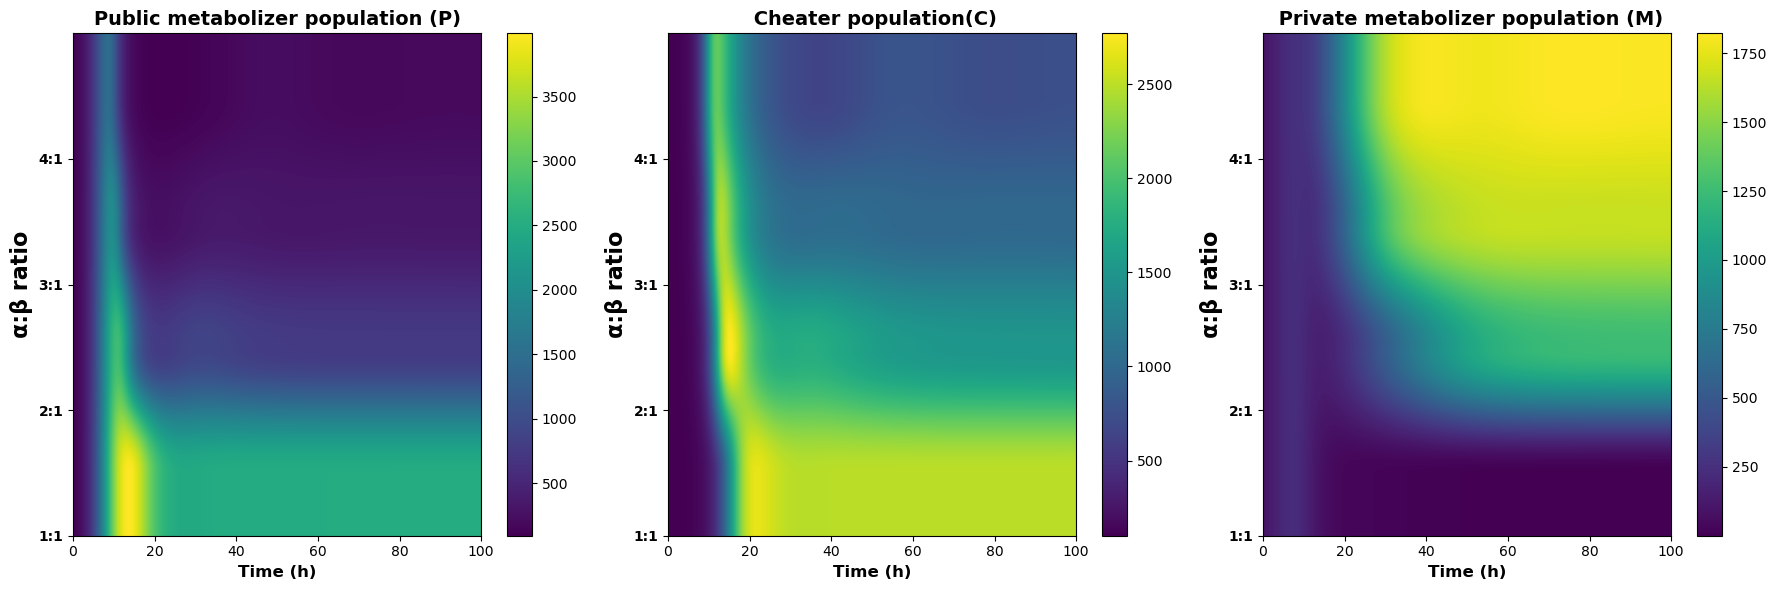

In [23]:
from src.model import deriv
from src.parameters import parameters
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import os

# Initial conditions and time vector
y0 = 100.0, 100.0, 100.0  # Initial populations of C, D, P
t = np.linspace(0, 100, 1000)  # Time range for simulation

# Define α (alpha) scaling factors
alpha_multipliers = [1, 2, 3, 4]  # α = k * β

# Reference β (beta) from parameters
base_beta = parameters["beta"]

# Matrices to store results for heatmap
pop_C = np.zeros((len(alpha_multipliers), len(t)))  # Public (C) over time for each scaling
pop_D = np.zeros((len(alpha_multipliers), len(t)))  # Cheater (D) over time for each scaling
pop_P = np.zeros((len(alpha_multipliers), len(t)))  # Private (P) over time for each scaling

# Simulate for each scaling of α (alpha)
for i, alpha_mult in enumerate(alpha_multipliers):
    alpha = base_beta * alpha_mult  # Scale α (alpha)
    beta = base_beta  # Keep β (beta) constant

    # Run the simulation
    ret = odeint(
        deriv, y0, t, args=(
            parameters["nu"],
            beta,
            alpha,
            parameters["r_c"],
            parameters["r_p"],
            parameters["gamma"],
            parameters["eta"],
        )
    )

    # Store population data for heatmap
    pop_C[i, :] = ret[:, 0]  # Public (C)
    pop_D[i, :] = ret[:, 1]  # Cheater (D)
    pop_P[i, :] = ret[:, 2]  # Private (P)

# Plot heatmaps for each population
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Heatmap for Public (C)
c1 = axs[0].imshow(pop_C, aspect='auto', cmap='viridis', origin='lower',
                   extent=[t[0], t[-1], 1, len(alpha_multipliers) + 1])
axs[0].set_title('Public metabolizer population (P)', fontsize=14, fontweight="bold")
axs[0].set_xlabel('Time (h)', fontsize=12, fontweight="bold")
axs[0].set_ylabel('α:β ratio', fontsize=16, fontweight="bold")
axs[0].set_yticks(range(1, len(alpha_multipliers) + 1))
axs[0].set_yticklabels([f"{k}:1" for k in alpha_multipliers], fontsize=10, fontweight="bold")
fig.colorbar(c1, ax=axs[0])

# Heatmap for Cheater (D)
c2 = axs[1].imshow(pop_D, aspect='auto', cmap='viridis', origin='lower',
                   extent=[t[0], t[-1], 1, len(alpha_multipliers) + 1])
axs[1].set_title(' Cheater population(C)', fontsize=14, fontweight="bold")
axs[1].set_xlabel('Time (h)', fontsize=12, fontweight="bold")
axs[1].set_ylabel('α:β ratio', fontsize=16, fontweight="bold")
axs[1].set_yticks(range(1, len(alpha_multipliers) + 1))
axs[1].set_yticklabels([f"{k}:1" for k in alpha_multipliers], fontsize=10, fontweight="bold")
fig.colorbar(c2, ax=axs[1])

# Heatmap for Private (P)
c3 = axs[2].imshow(pop_P, aspect='auto', cmap='viridis', origin='lower',
                   extent=[t[0], t[-1], 1, len(alpha_multipliers) + 1])
axs[2].set_title(' Private metabolizer population (M)', fontsize=14, fontweight="bold")
axs[2].set_xlabel('Time (h)', fontsize=12, fontweight="bold")
axs[2].set_ylabel('α:β ratio', fontsize=16, fontweight="bold")
axs[2].set_yticks(range(1, len(alpha_multipliers) + 1))
axs[2].set_yticklabels([f"{k}:1" for k in alpha_multipliers], fontsize=10, fontweight="bold")
fig.colorbar(c3, ax=axs[2])

# Save and show the heatmaps
os.makedirs("output/figures", exist_ok=True)  # Ensure the output directory exists
plt.tight_layout()
plt.savefig("output/figures/heatmap_alpha_scaled.png", dpi=300)
plt.show()


## high competition loss(beta)- 
public and cheater will survive with a miniman population density but private will extinct.

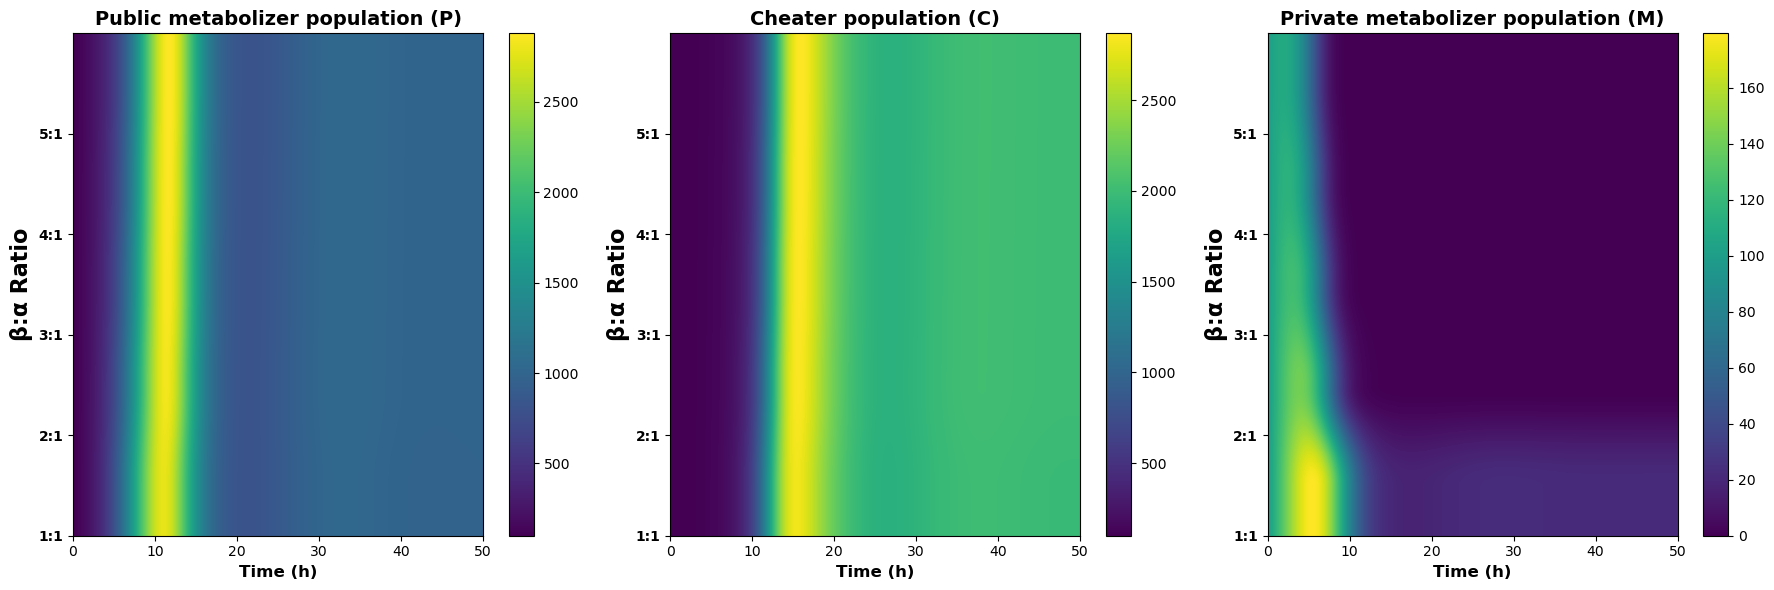

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from src.model import deriv
from src.parameters import parameters
from scipy.integrate import odeint
import os


# Initial conditions and time vector
y0 = 100.0, 100.0, 100.0  # Initial populations of C, D, P
t = np.linspace(0, 50, 1000)  # Time range for simulation

# Define β:α scaling factors
beta_multipliers = [1,2, 3, 4, 5]  # β = k * α

# Reference α (alpha) from parameters
base_alpha = parameters["alpha"]

# Matrices to store results for heatmap
pop_C = np.zeros((len(beta_multipliers), len(t)))  # Public (C) over time for each scaling
pop_D = np.zeros((len(beta_multipliers), len(t)))  # Cheater (D) over time for each scaling
pop_P = np.zeros((len(beta_multipliers), len(t)))  # Private (P) over time for each scaling

# Simulate for each scaling of β (beta)
for i, beta_mult in enumerate(beta_multipliers):
    beta = base_alpha * beta_mult  # Scale β (beta)
    alpha = base_alpha  # Keep α (alpha) constant

    # Run the simulation
    ret = odeint(
        deriv, y0, t, args=(
            parameters["nu"],
            beta,
            alpha,
            parameters["r_c"],
            parameters["r_p"],
            parameters["gamma"],
            parameters["eta"],
        )
    )

    # Store population data for heatmap
    pop_C[i, :] = ret[:, 0]  # Public (C)
    pop_D[i, :] = ret[:, 1]  # Cheater (D)
    pop_P[i, :] = ret[:, 2]  # Private (P)

# Plot heatmaps for each population
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Heatmap for Public (C)
c1 = axs[0].imshow(pop_C, aspect='auto', cmap='viridis', origin='lower',
                   extent=[t[0], t[-1], 1, len(beta_multipliers) + 1])
axs[0].set_title('Public metabolizer population (P)', fontsize=14, fontweight="bold")
axs[0].set_xlabel('Time (h)', fontsize=12, fontweight="bold")
axs[0].set_ylabel('β:α Ratio', fontsize=16, fontweight="bold")
axs[0].set_yticks(range(1, len(beta_multipliers) + 1))
axs[0].set_yticklabels([f"{k}:1" for k in beta_multipliers], fontsize=10, fontweight="bold")
fig.colorbar(c1, ax=axs[0])

# Heatmap for Cheater (D)
c2 = axs[1].imshow(pop_D, aspect='auto', cmap='viridis', origin='lower',
                   extent=[t[0], t[-1], 1, len(beta_multipliers) + 1])
axs[1].set_title('Cheater population (C)', fontsize=14, fontweight="bold")
axs[1].set_xlabel('Time (h)', fontsize=12, fontweight="bold")
axs[1].set_ylabel('β:α Ratio', fontsize=16, fontweight="bold")
axs[1].set_yticks(range(1, len(beta_multipliers) + 1))
axs[1].set_yticklabels([f"{k}:1" for k in beta_multipliers], fontsize=10, fontweight="bold")
fig.colorbar(c2, ax=axs[1])

# Heatmap for Private (P)
c3 = axs[2].imshow(pop_P, aspect='auto', cmap='viridis', origin='lower',
                   extent=[t[0], t[-1], 1, len(beta_multipliers) + 1])
axs[2].set_title('Private metabolizer population (M)', fontsize=14, fontweight="bold")
axs[2].set_xlabel('Time (h)', fontsize=12, fontweight="bold")
axs[2].set_ylabel('β:α Ratio', fontsize=16, fontweight="bold")
axs[2].set_yticks(range(1, len(beta_multipliers) + 1))
axs[2].set_yticklabels([f"{k}:1" for k in beta_multipliers], fontsize=10, fontweight="bold")
fig.colorbar(c3, ax=axs[2])

# Save and show the heatmaps
os.makedirs("output/figures", exist_ok=True)  # Ensure the output directory exists
plt.tight_layout()
plt.savefig("output/figures/heatmap_beta_scaled.png", dpi=300)
plt.show()


#  Parameter sensivity analysis(supplementary material)

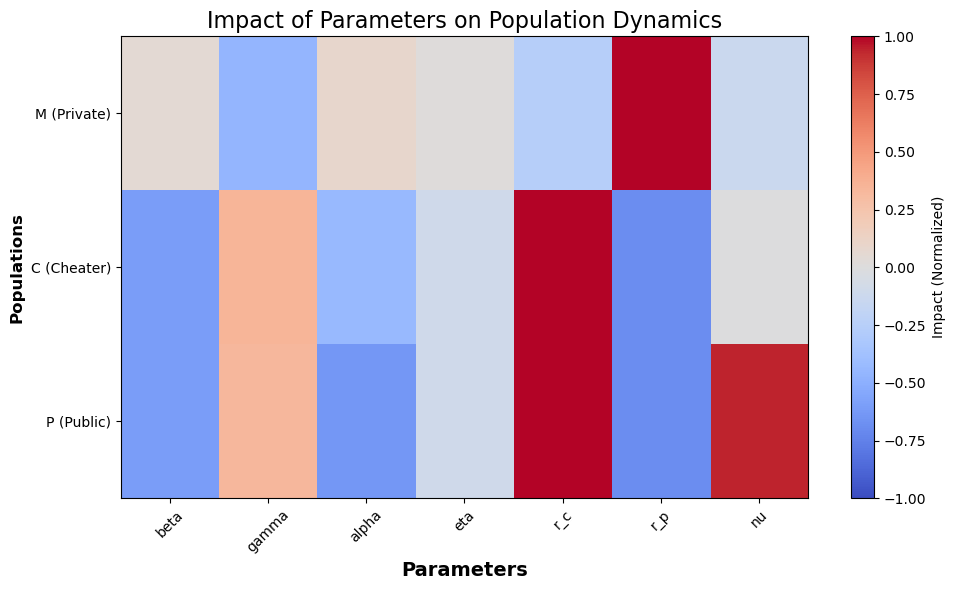

In [5]:
from src.model import deriv  # Import the ODE system
from src.parameters import parameters  # Import parameters
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import os

# Simulation configuration
simulation_config = {
    't_max': 200,  # Maximum simulation time
    'dt': 0.1,  # Time step
    'rc_rp_range': np.linspace(1, 3.0, 10),  # Parameter perturbation range
}

# Initial conditions and time vector
y0 = 100.0, 100.0, 100.0  # Initial populations of [C (Public), D (Cheater), P (Private)]
t_max, dt = simulation_config['t_max'], simulation_config['dt']  # Extract simulation settings
t = np.linspace(0, t_max, int(t_max / dt))  # Time vector for simulation

# Solve ODE system
ret = odeint(deriv, y0, t, args=(
    parameters["nu"],
    parameters["beta"],
    parameters["alpha"],
    parameters["r_c"],
    parameters["r_p"],
    parameters["gamma"],
    parameters["eta"],
))

# Extract growth rates 
C, D, P = ret[:, 0], ret[:, 1], ret[:, 2]

# Relative Contributions of Parameters (Metabolic Control Analysis)
def perform_metabolic_control_analysis():
    
    parameter_names = [param for param in parameters.keys() if param not in ["sigma_c", "sigma_p"]]
    impact_matrix = np.zeros((3, len(parameter_names)))  # Rows: Populations, Columns: Parameters

    for j, param_name in enumerate(parameter_names):
        impacts = []

        for factor in simulation_config['rc_rp_range']:
            # Perturb parameter
            perturbed_params = parameters.copy()
            perturbed_params[param_name] *= factor
            ret_perturbed = odeint(deriv, y0, t, args=(
                perturbed_params["nu"],
                perturbed_params["beta"],
                perturbed_params["alpha"],
                perturbed_params["r_c"],
                perturbed_params["r_p"],
                perturbed_params["gamma"],
                perturbed_params["eta"],
            ))
            C_perturbed, D_perturbed, P_perturbed = ret_perturbed[:, 0], ret_perturbed[:, 1], ret_perturbed[:, 2]

            # Calculate relative impacts for populations
            impacts.append([
                (np.sum(C_perturbed)- np.sum(C)) / np.sum(C) if np.sum(C_perturbed) != 0 else 0,
                ( np.sum(D_perturbed)- np.sum(D)) / np.sum(D)  if np.sum(D_perturbed) != 0 else 0,
                ( np.sum(P_perturbed) - np.sum(P) ) / np.sum(P) if np.sum(P_perturbed) != 0 else 0,
            ])

        # Average impact over the range
        impact_matrix[:, j] = np.mean(impacts, axis=0)

    return impact_matrix, parameter_names

impact_matrix, parameter_names = perform_metabolic_control_analysis()

# Plotting the Heatmap
def plot_impact_heatmap(impact_matrix, parameter_names):
    
    plt.figure(figsize=(10, 6))
    plt.imshow(impact_matrix, aspect='auto', cmap='coolwarm', origin='lower', vmin=-1, vmax=1)
    plt.colorbar(label='Impact (Normalized)')
    plt.xticks(range(len(parameter_names)), labels=parameter_names, rotation=45)
    plt.yticks(range(3), labels=['P (Public)', 'C (Cheater)', 'M (Private)'])
    plt.title('Impact of Parameters on Population Dynamics', fontsize=16)
    plt.xlabel('Parameters', fontsize=14, fontweight="bold")
    plt.ylabel('Populations', fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("output/impact_heatmap.png", dpi=300)
    plt.show()

# Execute heatmap plotting
plot_impact_heatmap(impact_matrix, parameter_names)


#  Growth rate impact on population

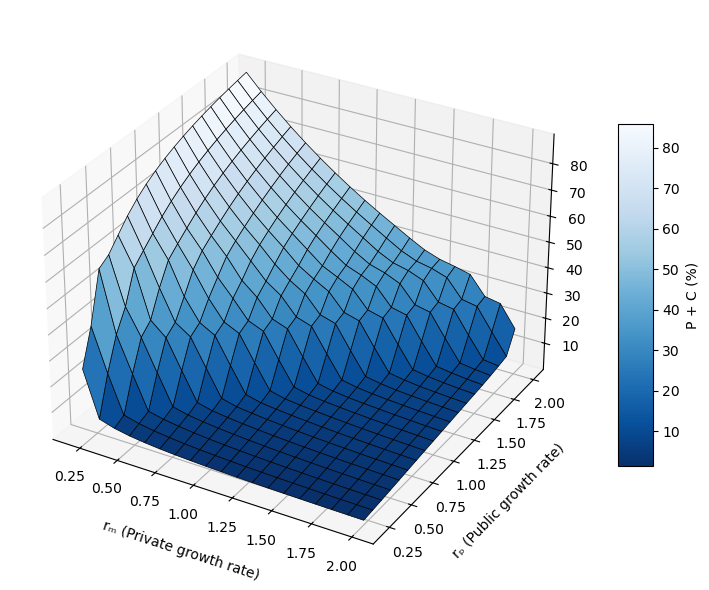

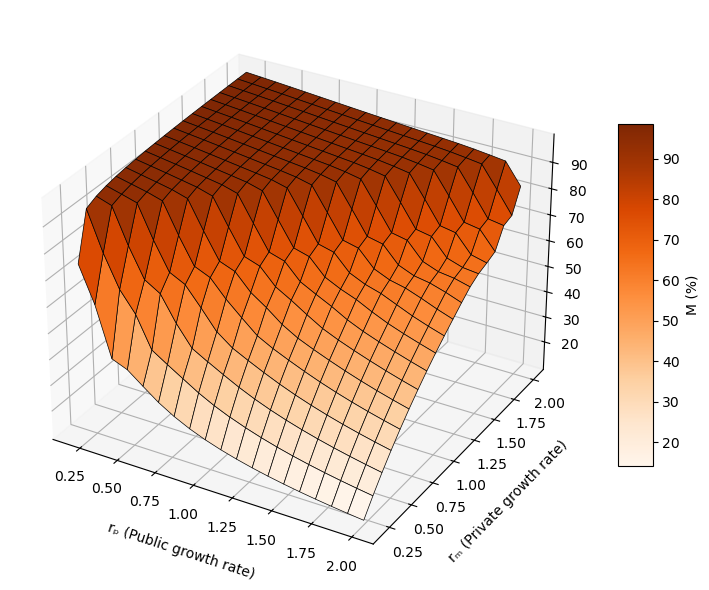

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# -------- Parameters and Setup --------
base = dict(alpha=0.0002, beta=0.0001,
            eta=0.0001, gamma=0.0001, nu=0.00001)
rp_vals = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4, 1.5,1.6,1.7,1.8,1.9, 2.0]
rm_vals = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0]

def simplex_grid(n=10):
    return np.array([[a/n, b/n, (n-a-b)/n]
                     for a in range(n+1) for b in range(n+1-a)])

grid = simplex_grid()
t = np.linspace(0, 300, 800)

# -------- Dynamics --------
def dyn(x, t, p):
    P, C, M = x
    return [
        p['r_p']*P - p['alpha']*P*C - p['beta']*P*M - p['eta']*P**2,
        p['alpha']*P*C - p['nu']*C**2,
        p['r_m']*M - p['beta']*M*P - p['gamma']*M**2
    ]

# -------- Simulate Dynamics --------
res = {}
for i, rp in enumerate(rp_vals):
    for j, rm in enumerate(rm_vals):
        p = base.copy()
        p['r_p'] = rp
        p['r_m'] = rm
        finals = np.array([odeint(dyn, x0, t, args=(p,))[-1] for x0 in grid])
        avg = finals.mean(axis=0)
        res[(i, j)] = {
            'r_p': rp,
            'r_m': rm,
            'prop': avg / avg.sum(),
            'total': avg.sum()
        }

rp_vals_grid, rm_vals_grid = [], []
p_props, c_props, m_props = [], [], []

for (i, j), d in res.items():
    rp_vals_grid.append(d['r_p'])
    rm_vals_grid.append(d['r_m'])
    p_props.append(d['prop'][0])
    c_props.append(d['prop'][1])
    m_props.append(d['prop'][2])

# Reshape to 2D
rp_vals_grid = np.array(rp_vals_grid).reshape(len(rp_vals), len(rm_vals))
rm_vals_grid = np.array(rm_vals_grid).reshape(len(rp_vals), len(rm_vals))
p_props = np.array(p_props).reshape(len(rp_vals), len(rm_vals))
c_props = np.array(c_props).reshape(len(rp_vals), len(rm_vals))
m_props = np.array(m_props).reshape(len(rp_vals), len(rm_vals))

# Compute percentages
pc_props_percent = (p_props + c_props) * 100
m_props_percent = m_props * 100

# -------- Plot P + C (%) with Swapped Axes --------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(rm_vals_grid, rp_vals_grid, pc_props_percent,
                       cmap=cm.Blues_r, edgecolor='k', linewidth=0.5)
ax.set_xlabel('rₘ (Private growth rate)', labelpad=10)
ax.set_ylabel('rₚ (Public growth rate)', labelpad=10)
#ax.set_title('Public (P) + Cheater (C) Population Percentage', pad=15)
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10)
cbar.set_label('P + C (%)')
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(rp_vals_grid, rm_vals_grid, m_props_percent,
                       cmap=cm.Oranges, edgecolor='k', linewidth=0.5)
ax.set_xlabel('rₚ (Public growth rate)', labelpad=10)
ax.set_ylabel('rₘ (Private growth rate)', labelpad=10)


#ax.set_title('Private (M) Population Percentage', pad=15)
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10)
cbar.set_label('M (%)')
plt.tight_layout()
plt.savefig("output/figures/3d growth rate.png", dpi=300)
plt.show()


# Numerical lab evolution (shift in population)

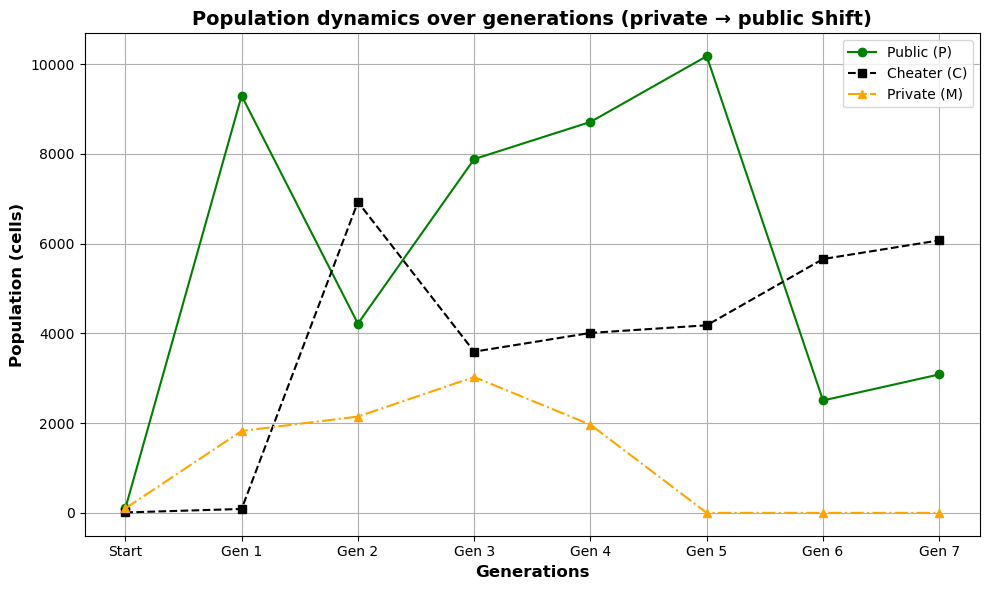

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from src.model import deriv  # Import model function
from src.parameters import parameters  # Import parameters dictionary

# **Time settings**
T = 4  # Total simulation time for each generation
dt = 0.1
time = np.linspace(0, T, int(T/dt))

# **Initial conditions** (before Generation 1 starts)
C_init, D_init, P_init = 100, 10, 100  # Initial population values
generations = ["Start", "Gen 1", "Gen 2", "Gen 3", "Gen 4", "Gen 5", "Gen 6","Gen 7"]

# **Store population values for plotting**
public_pop = [C_init]   # Store initial Public (C) population
cheater_pop = [D_init]  # Store initial Cheater (D) population
private_pop = [P_init]  # Store initial Private (P) population
total_pop = [C_init + D_init + P_init]  # Track total population

# **Define transition rates for each generation (Private → Public shift)**
shift_ratios = [0.3, 0.5, 0.7, 0.8, 1, 0, 0]  # Shift percentages

# **Run simulation for each generation**
y0 = [C_init, D_init, P_init]  # Initial population
for shift in shift_ratios:
    # **Run simulation for the current generation**
    sol = odeint(deriv, y0, time, args=(
        parameters["nu"],
        parameters["beta"],
        parameters["alpha"],
        parameters["r_c"],
        parameters["r_p"],
        parameters["gamma"],
        parameters["eta"],
    ))

    # **Extract final population values at the end of the generation**
    final_C, final_D, final_P = sol[-1]

    # **Modify population for next generation shift**
    new_C = final_C + (final_P * shift)  # Public receives shifted Private
    new_P = final_P * (1 - shift)  # Private decreases
    new_D = final_D  # Cheater remains unchanged

    # **Store values for plotting**
    public_pop.append(new_C)
    private_pop.append(new_P)
    cheater_pop.append(new_D)
    total_pop.append(new_C + new_D + new_P)  # Compute total population

    # **Update initial conditions for next generation**
    y0 = [new_C, new_D, new_P]

# **Plot Results**
plt.figure(figsize=(10, 6))

# **Ensure lists have the same length**
if len(generations) == len(public_pop):
    # **Plot Public (C) shift**
    plt.plot(generations, public_pop, marker="o", linestyle="-", color="green", label="Public (P)")

    # **Plot Cheater (D) population**
    plt.plot(generations, cheater_pop, marker="s", linestyle="--", color="black", label="Cheater (C)")

    # **Plot Private (P) population**
    plt.plot(generations, private_pop, marker="^", linestyle="-.", color="orange", label="Private (M)")

    # **Formatting**
    plt.xlabel("Generations", fontsize=12, fontweight="bold")
    plt.ylabel("Population (cells)", fontsize=12, fontweight="bold")
    plt.title("Population dynamics over generations (private → public Shift)", fontsize=14, fontweight="bold")
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()

    # **Save & show the figure**
    plt.savefig("output/figures/private_to_public_shift.png", dpi=300)
    plt.show()
else:
    print(f"Mismatch: Generations ({len(generations)}) vs Population Data ({len(public_pop)})")


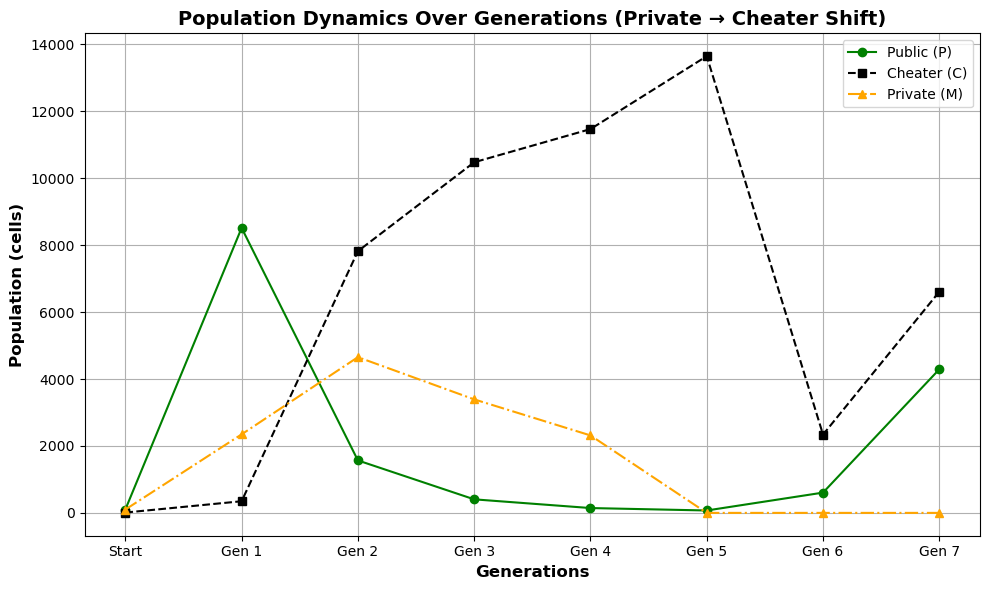

In [33]:
# **Time settings**
T = 4  # Total simulation time for each generation
dt = 0.1
time = np.linspace(0, T, int(T/dt))

# **Initial conditions** (before Generation 1 starts)
C_init, D_init, P_init = 100, 10, 100  # Initial population values
generations = ["Start", "Gen 1", "Gen 2", "Gen 3", "Gen 4", "Gen 5", "Gen 6","Gen 7"]

# **Store population values for plotting**
public_pop = [C_init]   # Store initial Public (C) population
cheater_pop = [D_init]  # Store initial Cheater (D) population
private_pop = [P_init]  # Store initial Private (P) population
total_pop = [C_init + D_init + P_init]  # Track total population

# **Define transition rates for each generation (Private → Cheater shift)**
shift_ratios = [0.1, 0.3, 0.7, 0.8, 1.0, 0,0]  # Shift percentages

# **Run simulation for each generation**
y0 = [C_init, D_init, P_init]  # Initial population
for shift in shift_ratios:
    # **Run simulation for the current generation**
    sol = odeint(deriv, y0, time, args=(
        parameters["nu"],
        parameters["beta"],
        parameters["alpha"],
        parameters["r_c"],
        parameters["r_p"],
        parameters["gamma"],
        parameters["eta"],
    ))

    # **Extract final population values at the end of the generation**
    final_C, final_D, final_P = sol[-1]

    # **Modify population for next generation shift**
    new_D = final_D + (final_P * shift)  # Cheater receives shifted Private
    new_P = final_P * (1 - shift)  # Private decreases
    new_C = final_C  # Public remains unchanged

    # **Store values for plotting**
    public_pop.append(new_C)
    private_pop.append(new_P)
    cheater_pop.append(new_D)
    total_pop.append(new_C + new_D + new_P)  # Compute total population

    # **Update initial conditions for next generation**
    y0 = [new_C, new_D, new_P]

# **Plot Results**
plt.figure(figsize=(10, 6))

# **Ensure lists have the same length**
if len(generations) == len(public_pop):
    # **Plot Public (C) shift**
    plt.plot(generations, public_pop, marker="o", linestyle="-", color="green", label="Public (P)")

    # **Plot Cheater (D) population**
    plt.plot(generations, cheater_pop, marker="s", linestyle="--", color="black", label="Cheater (C)")

    # **Plot Private (P) population**
    plt.plot(generations, private_pop, marker="^", linestyle="-.", color="orange", label="Private (M)")

    # **Formatting**
    plt.xlabel("Generations", fontsize=12, fontweight="bold")
    plt.ylabel("Population (cells)", fontsize=12, fontweight="bold")
    plt.title("Population Dynamics Over Generations (Private → Cheater Shift)", fontsize=14, fontweight="bold")
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()

    # **Save & show the figure**
    plt.savefig("output/figures/private_to_cheater_shift.png", dpi=300)
    plt.show()
else:
    print(f"Mismatch: Generations ({len(generations)}) vs Population Data ({len(public_pop)})")
